# CycleSense

# Notebook 08: Model Explainability using SHAP

## Objective

Healthcare machine learning models should not only make accurate predictions but also provide interpretable explanations.

In this notebook, we use SHAP (SHapley Additive exPlanations) to understand how different menstrual health features influence ovulation day predictions made by the best-performing Gradient Boosting model.

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [4]:
from sklearn.model_selection import train_test_split

from src.config import (
    PROCESSED_DATA_DIR,
    MODEL_DIR,
    REPORT_DIR
)

from src.utils import load_model

In [5]:
X = pd.read_csv(
    PROCESSED_DATA_DIR / "X_ovulation.csv"
)

y = pd.read_csv(
    PROCESSED_DATA_DIR / "y_ovulation.csv"
).squeeze()

print(X.shape)
print(y.shape)

(1653, 77)
(1653,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
pipeline = load_model(
    MODEL_DIR / "best_ovulation_model.pkl"
)

pipeline

,steps,"[('imputer', ...), ('selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,score_func,<function mut...001C3E591B7F0>


In [8]:
pipeline.named_steps

{'imputer': SimpleImputer(strategy='median'),
 'selector': SelectKBest(k=25,
             score_func=<function mutual_info_regression at 0x000001C3E591B7F0>),
 'model': GradientBoostingRegressor(random_state=42)}

In [9]:
imputer = pipeline.named_steps["imputer"]

selector = pipeline.named_steps["selector"]

model = pipeline.named_steps["model"]

In [10]:
X_test_imputed = imputer.transform(X_test)

X_test_selected = selector.transform(X_test_imputed)

In [11]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_selected)

In [12]:
selected_features = X.columns[
    selector.get_support()
]

selected_features

Index(['Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle',
       'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays',
       'TotalNumberofPeakDays', 'TotalDaysofFertility',
       'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayThree',
       'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine',
       'TotalMensesScore', 'NumberofDaysofIntercourse',
       'IntercourseInFertileWindow', 'Religion', 'OccupationM', 'Weight',
       'Miscarriages', 'Medvits', 'LivingkidsM', 'BMI'],
      dtype='object')

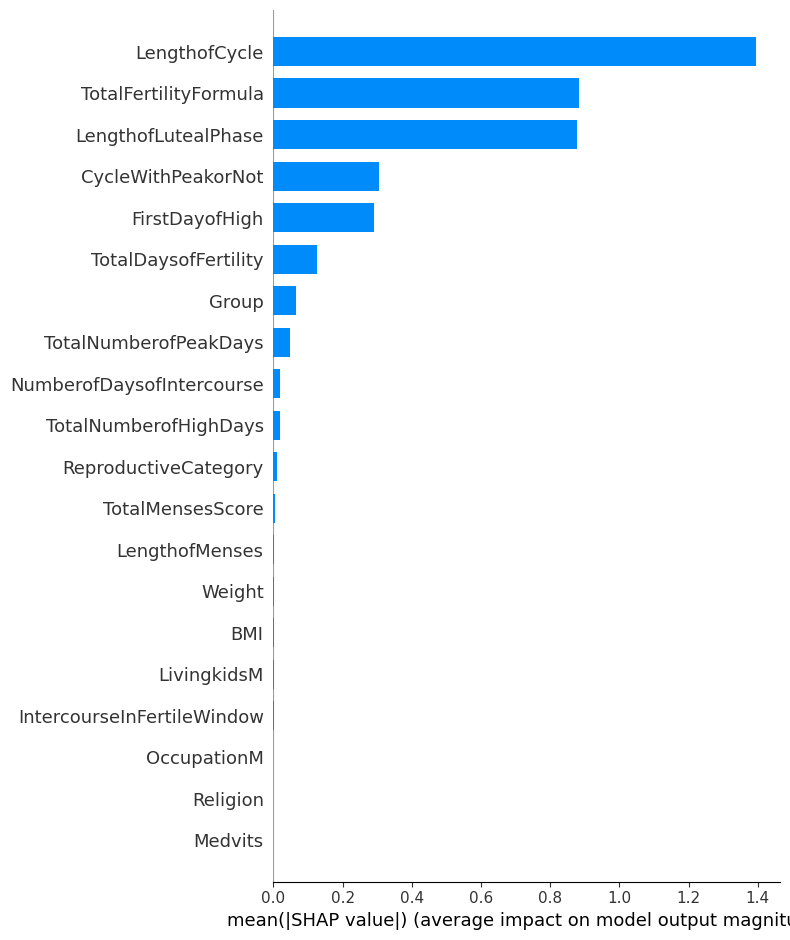

In [13]:
shap.summary_plot(

    shap_values,

    X_test_selected,

    feature_names=selected_features,

    plot_type="bar"

)

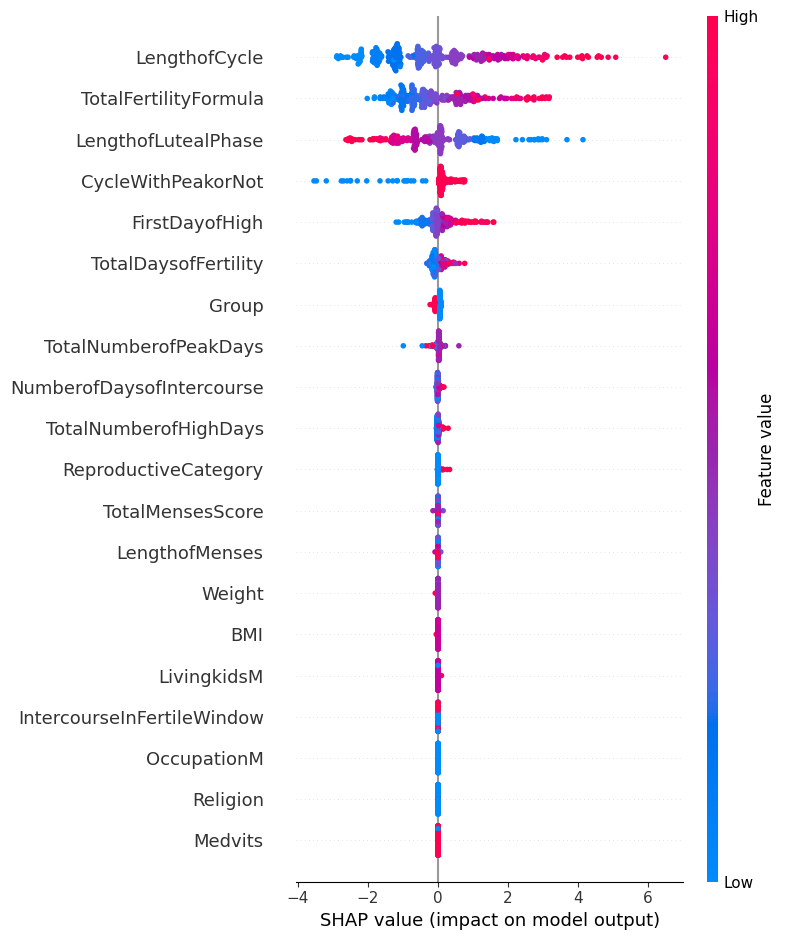

In [14]:
shap.summary_plot(

    shap_values,

    X_test_selected,

    feature_names=selected_features

)

In [15]:
importance = pd.DataFrame({

    "Feature": selected_features,

    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)

})

importance = importance.sort_values(

    "Mean |SHAP|",

    ascending=False

)

importance

,Feature,Mean |SHAP|
3,LengthofCycle,1.394459
9,TotalFertilityFormula,0.884263
4,LengthofLutealPhase,0.876690
1,CycleWithPeakorNot,0.304712
5,FirstDayofHigh,0.290019
8,TotalDaysofFertility,0.126320
0,Group,0.066504
7,TotalNumberofPeakDays,0.048338
16,NumberofDaysofIntercourse,0.019664
6,TotalNumberofHighDays,0.018369


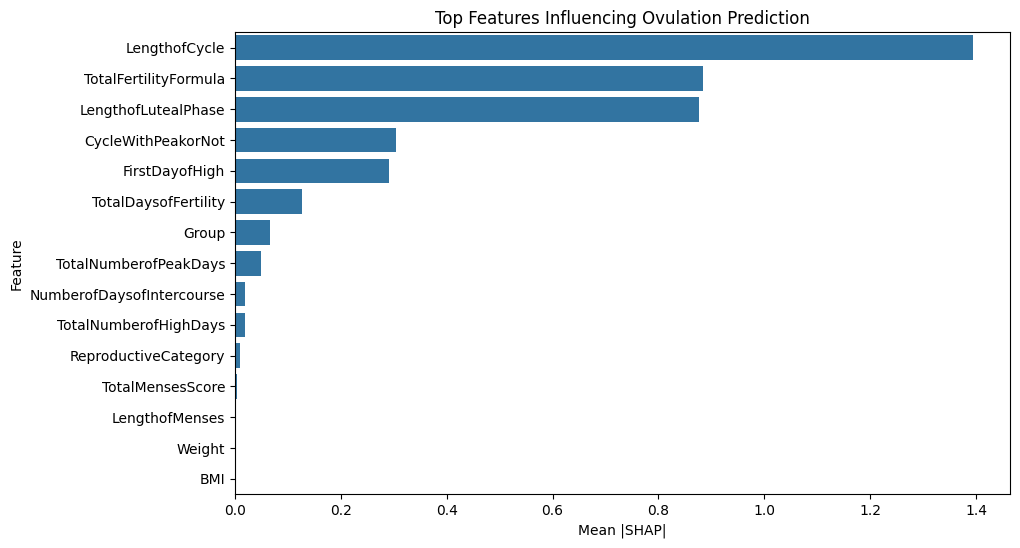

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x="Mean |SHAP|",

    y="Feature"

)

plt.title("Top Features Influencing Ovulation Prediction")

plt.show()

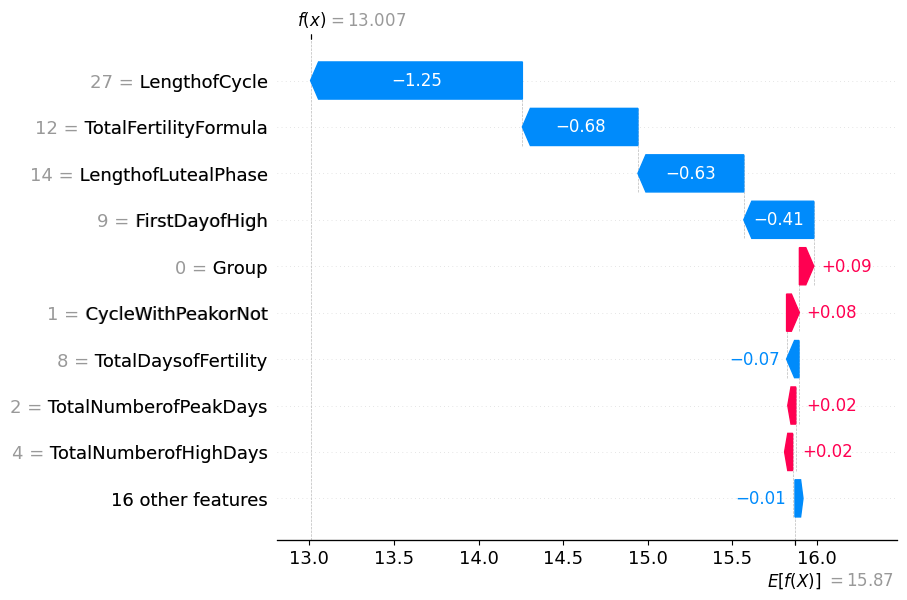

In [17]:
sample = 0

explanation = shap.Explanation(

    values=shap_values[sample],

    base_values=explainer.expected_value,

    data=X_test_selected[sample],

    feature_names=selected_features

)

shap.plots.waterfall(explanation)

In [18]:
shap.initjs()

shap.force_plot(

    explainer.expected_value,

    shap_values[0],

    X_test_selected[0],

    feature_names=selected_features

)

In [19]:
REPORT_DIR.mkdir(exist_ok=True)

importance.to_csv(

    REPORT_DIR / "shap_feature_importance.csv",

    index=False

)

print("SHAP feature importance saved.")

SHAP feature importance saved.


In [21]:
import pandas as pd
from pathlib import Path

report_dir = Path("../reports")
report_dir.mkdir(exist_ok=True)

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    report_dir / "shap_feature_importance.csv",
    index=False
)

feature_importance.head(10)

ValueError: All arrays must be of the same length

In [26]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'Path', 'report_dir', '_i2', 'warnings', '_i3', 'np', 'plt', 'sns', 'shap', '_i4', 'train_test_split', 'PROCESSED_DATA_DIR', 'MODEL_DIR', 'REPORT_DIR', 'load_model', '_i5', 'X', 'y', '_i6', 'X_train', 'X_test', 'y_train', 'y_test', '_i7', 'pipeline', '_7', '_i8', '_8', '_i9', 'imputer', 'selector', 'model', '_i10', 'X_test_imputed', 'X_test_selected', '_i11', 'explainer', 'shap_values', '_i12', 'selected_features', '_12', '_i13', '_i14', '_i15', 'importance', '_15', '_i16', '_i17', 'sample', 'explanation', '_i18', '_18', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26'])

In [22]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [23]:
print(np.array(shap_values).shape)

(331, 25)


In [24]:
print(X_train.shape)

(1322, 77)


In [25]:
print(len(X_train.columns))

77


In [27]:
print(len(selected_features))
print(selected_features)

25
Index(['Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle',
       'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays',
       'TotalNumberofPeakDays', 'TotalDaysofFertility',
       'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayThree',
       'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine',
       'TotalMensesScore', 'NumberofDaysofIntercourse',
       'IntercourseInFertileWindow', 'Religion', 'OccupationM', 'Weight',
       'Miscarriages', 'Medvits', 'LivingkidsM', 'BMI'],
      dtype='object')


In [28]:
import numpy as np
import pandas as pd
from pathlib import Path

report_dir = Path("../reports")
report_dir.mkdir(exist_ok=True)

importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": list(selected_features),
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    report_dir / "shap_feature_importance.csv",
    index=False
)

feature_importance.head(10)

,Feature,Importance
3,LengthofCycle,1.394459
9,TotalFertilityFormula,0.884263
4,LengthofLutealPhase,0.876690
1,CycleWithPeakorNot,0.304712
5,FirstDayofHigh,0.290019
8,TotalDaysofFertility,0.126320
0,Group,0.066504
7,TotalNumberofPeakDays,0.048338
16,NumberofDaysofIntercourse,0.019664
6,TotalNumberofHighDays,0.018369


# Interpretation

The SHAP analysis highlights the contribution of each selected feature to the predicted ovulation day.

### Key Findings

- Features with larger SHAP values have greater influence on the model's predictions.
- Positive SHAP values increase the predicted ovulation day.
- Negative SHAP values decrease the prediction.
- The model primarily relies on physiological and menstrual-cycle characteristics, improving interpretability for healthcare applications.

This analysis enhances transparency and trust in the machine learning model.